# GeoPol Risk Monitor — Quand la géopolitique bouge le pétrole
  
## C'est quoi ce projet ?

J'ai voulu comprendre comment les crises géopolitiques (Iran, Russie, Moyen-Orient) impactent concrètement le prix des options sur le pétrole Brent.

Pour ça, j'ai utilisé deux outils classiques de la finance de marché :
- **Black-Scholes** : pour calculer le prix théorique d'une option
- **Monte Carlo** : pour simuler des milliers de trajectoires possibles du prix du baril

Ce notebook suit ma progression pas à pas. Je suis débutant — j'ai commenté chaque ligne pour que ce soit clair.


## Plan du notebook

1. Les imports et les données réelles (Brent)
2. Le modèle Black-Scholes — pricing d'une option Call
3. La volatilité historique — mesurer la nervosité du marché
4. Monte Carlo — simuler l'incertitude
5. Surface 3D — visualiser le risque en scénario de crise géopolitique

## 1. Imports et données réelles

On commence par charger les bibliothèques qu'on va utiliser, puis les vraies données du pétrole Brent.

In [14]:
# Les bibliothèques essentielles
import numpy as np                  # Calculs mathématiques
import pandas as pd                 # Manipulation de données
import matplotlib.pyplot as plt     # Graphiques
from scipy.stats import norm        # Loi normale (nécessaire pour Black-Scholes)
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

print("Bibliothèques chargées avec succès !")

Bibliothèques chargées avec succès !


In [15]:
# Chargement des données réelles du Brent
# Le fichier CSV contient deux colonnes : Date et Price
df = pd.read_csv('BentOil.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Nombre de jours de données : {len(df)}")
print(f"Période : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Dernier prix du baril : {df['Price'].iloc[-1]:.2f} $")

df.tail(5)

Nombre de jours de données : 2131
Période : 2018-01-02 → 2026-04-02
Dernier prix du baril : 109.03 $


,Date,Price,Open,High,Low,Vol.,Change %
2126,2026-03-27,112.57,106.60,114.88,105.09,104.03K,4.22%
2127,2026-03-30,112.78,114.50,116.89,111.41,129.59K,0.19%
2128,2026-03-31,118.35,115.04,119.24,111.35,18.80K,4.94%
2129,2026-04-01,101.16,103.63,105.94,98.35,530.80K,-14.52%
2130,2026-04-02,109.03,100.70,109.74,99.08,512.52K,7.78%


## 2. Le modèle Black-Scholes

Black-Scholes est le modèle de référence pour pricer une option. Il répond à cette question :

> "Combien vaut le droit d'acheter un baril de pétrole à un prix fixé, à une date future ?"

### Les 5 paramètres du modèle :

| Paramètre | Symbole | Signification |
|-----------|---------|---------------|
| Prix actuel | S | Le prix du baril aujourd'hui |
| Strike | K | Le prix auquel on veut acheter dans le futur |
| Temps | T | Durée jusqu'à l'échéance (en années) |
| Taux sans risque | r | Le taux d'intérêt de référence |
| Volatilité | σ | La nervosité du marché — c'est LE paramètre clé |

### La formule :

$$C = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2) \cdot T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [16]:
def black_scholes_call(S, K, T, r, sigma):
    """
    Calcule le prix d'une option Call avec le modèle Black-Scholes.
    
    Paramètres :
        S     : Prix actuel du sous-jacent (baril de Brent)
        K     : Prix d'exercice (strike)
        T     : Temps jusqu'à l'échéance (en années)
        r     : Taux sans risque annuel
        sigma : Volatilité annuelle
    
    Retourne :
        Le prix théorique de l'option Call
    """
    # d1 et d2 sont des variables intermédiaires de la formule
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # norm.cdf = fonction de répartition de la loi normale
    # Elle donne la probabilité que le prix finisse au-dessus du strike
    call_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
    return call_price


# Test rapide avec des paramètres simples
prix_option_normal = black_scholes_call(
    S=80,      # Baril à 80$
    K=85,      # On veut l'acheter à 85$ dans 3 mois
    T=0.25,    # 3 mois = 0.25 an
    r=0.03,    # Taux sans risque 3%
    sigma=0.20 # Volatilité normale : 20%
)

print(f"Prix de l'option en temps calme (vol = 20%) : {prix_option_normal:.2f} $")

Prix de l'option en temps calme (vol = 20%) : 1.55 $


## 3. La volatilité historique — mesurer la nervosité du marché

La volatilité c'est LE paramètre qui change tout dans Black-Scholes.

En temps normal : ~20-30%  
En crise géopolitique (invasion Ukraine, conflit Iran-USA) : peut monter à 60-80%

On la calcule à partir des vraies données Brent :

In [17]:
# Calcul des rendements logarithmiques journaliers
# log(P_t / P_{t-1}) = variation relative du prix en %
df['Returns'] = np.log(df['Price'] / df['Price'].shift(1))

# Volatilité historique annualisée
# On multiplie par sqrt(252) car il y a 252 jours de trading par an
hist_vol = df['Returns'].std() * np.sqrt(252)

print(f"Dernier prix du baril : {df['Price'].iloc[-1]:.2f} $")
print(f"Volatilité historique annualisée : {hist_vol:.2%}")
print()
print("Pour comparaison :")
print("  Marché calme   : ~20-30%")
print("  Crise normale  : ~40-50%")
print("  Crise extrême  : ~70-80%")

Dernier prix du baril : 109.03 $
Volatilité historique annualisée : 40.69%

Pour comparaison :
  Marché calme   : ~20-30%
  Crise normale  : ~40-50%
  Crise extrême  : ~70-80%


## 4. Monte Carlo — simuler l'incertitude

Monte Carlo c'est simple : au lieu d'une seule formule, on simule **des milliers de trajectoires possibles** du prix du Brent.

Chaque trajectoire représente un futur possible. La moyenne de tous les payoffs nous donne le prix de l'option.

### Comparaison Black-Scholes vs Monte Carlo

Les deux doivent donner des résultats très proches — c'est notre validation !

In [18]:
def monte_carlo_price(S, K, T, r, sigma, iterations=100000):
    """
    Calcule le prix d'une option Call par simulation Monte Carlo.
    
    On simule 'iterations' trajectoires aléatoires du prix à l'échéance T,
    puis on calcule le payoff moyen actualisé.
    """
    # Génération de 'iterations' nombres aléatoires (loi normale)
    z = np.random.standard_normal(iterations)
    
    # Prix final simulé à l'échéance T (mouvement brownien géométrique)
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    
    # Payoff d'une Call : max(S_T - K, 0)
    # Si le prix finit sous le strike, l'option ne vaut rien
    payoffs = np.maximum(S_T - K, 0)
    
    # Actualisation au taux sans risque
    return np.exp(-r * T) * np.mean(payoffs)


# Paramètres basés sur les vraies données
S_last = df['Price'].iloc[-1]      # Dernier prix réel du Brent
K_target = S_last * 1.1            # Strike 10% au-dessus du prix actuel
T = 0.5                            # 6 mois
r = 0.04                           # Taux sans risque 4%

prix_bs = black_scholes_call(S_last, K_target, T, r, hist_vol)
prix_mc = monte_carlo_price(S_last, K_target, T, r, hist_vol)

print(f"Prix actuel du Brent : {S_last:.2f} $")
print(f"Strike (K) : {K_target:.2f} $")
print(f"Volatilité utilisée : {hist_vol:.2%}")
print()
print(f"Prix Black-Scholes : {prix_bs:.4f} $")
print(f"Prix Monte Carlo   : {prix_mc:.4f} $")
print(f"Ecart : {abs(prix_bs - prix_mc):.4f} $  (normal si < 0.10$)")

Prix actuel du Brent : 109.03 $
Strike (K) : 119.93 $
Volatilité utilisée : 40.69%

Prix Black-Scholes : 9.1329 $
Prix Monte Carlo   : 9.0534 $
Ecart : 0.0795 $  (normal si < 0.10$)


In [19]:
# Impact de la géopolitique sur le prix de l'option
# On compare 3 scénarios de volatilité

scenarios = {
    'Marché calme': 0.25,
    'Tensions modérées': 0.45,
    'Crise Iran-USA (guerre)': 0.80
}

print("Impact de la volatilité géopolitique sur le prix de l'option :")
print("-" * 55)
print(f"{'Scénario':<25} {'Volatilité':>12} {'Prix Call':>12}")
print("-" * 55)

for scenario, vol in scenarios.items():
    prix = black_scholes_call(S_last, K_target, T, r, vol)
    print(f"{scenario:<25} {vol:>11.0%} {prix:>11.2f} $")

Impact de la volatilité géopolitique sur le prix de l'option :
-------------------------------------------------------
Scénario                    Volatilité    Prix Call
-------------------------------------------------------
Marché calme                      25%        4.43 $
Tensions modérées                 45%       10.45 $
Crise Iran-USA (guerre)           80%       21.18 $


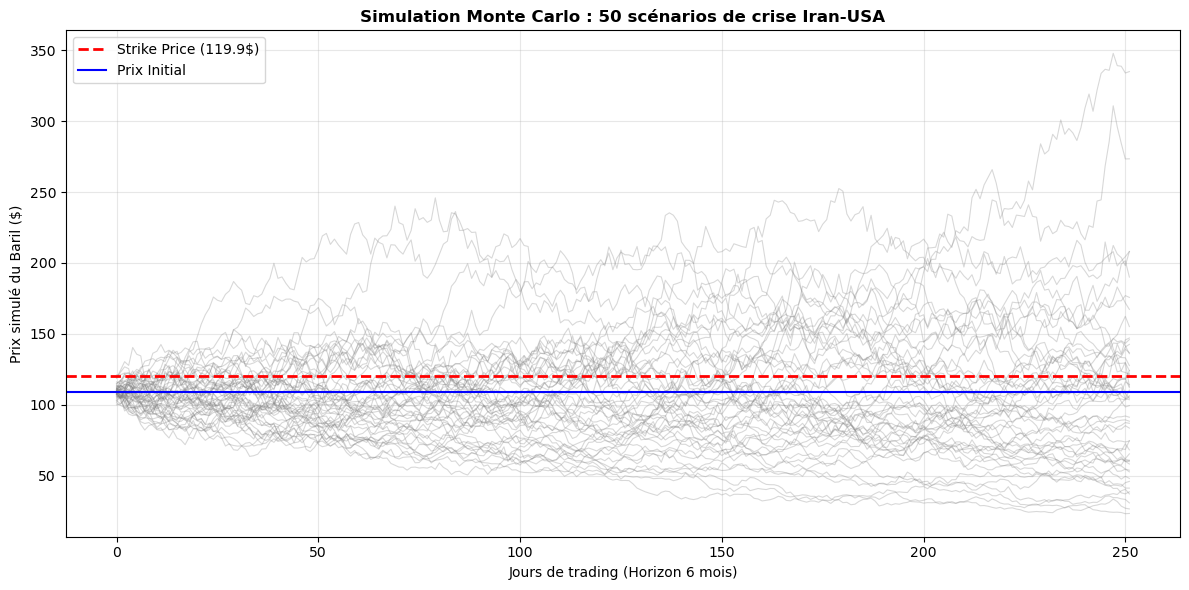

In [20]:
# Visualisation des trajectoires Monte Carlo — Scénario crise Iran-USA
vol_guerre = 0.80  # Volatilité en cas de conflit majeur
n_paths = 50
n_steps = 252      # 252 jours de trading = 1 an
dt = T / n_steps

plt.figure(figsize=(12, 6))

for _ in range(n_paths):
    z = np.random.standard_normal(n_steps)
    # Mouvement brownien géométrique : simulation jour par jour
    paths = S_last * np.exp(
        np.cumsum((r - 0.5 * vol_guerre**2) * dt + vol_guerre * np.sqrt(dt) * z)
    )
    plt.plot(paths, color='grey', alpha=0.3, lw=0.8)

plt.axhline(K_target, color='red', linestyle='--', lw=2, label=f'Strike Price ({K_target:.1f}$)')
plt.axhline(S_last, color='blue', lw=1.5, label='Prix Initial')
plt.title(f"Simulation Monte Carlo : {n_paths} scénarios de crise Iran-USA", fontweight='bold')
plt.xlabel("Jours de trading (Horizon 6 mois)")
plt.ylabel("Prix simulé du Baril ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Surface 3D — Visualiser le risque géopolitique

Ce graphique montre le prix de l'option Call pour **toutes les combinaisons possibles** de prix du baril et d'échéance, en scénario de crise géopolitique (vol = 80%).

Ce qu'on voit clairement :
- Plus le prix du baril monte → plus l'option vaut cher
- Plus l'échéance est longue → plus l'option vaut cher (plus de temps = plus d'incertitude)
- En crise, toute la surface "gonfle" — c'est l'effet **Vega**

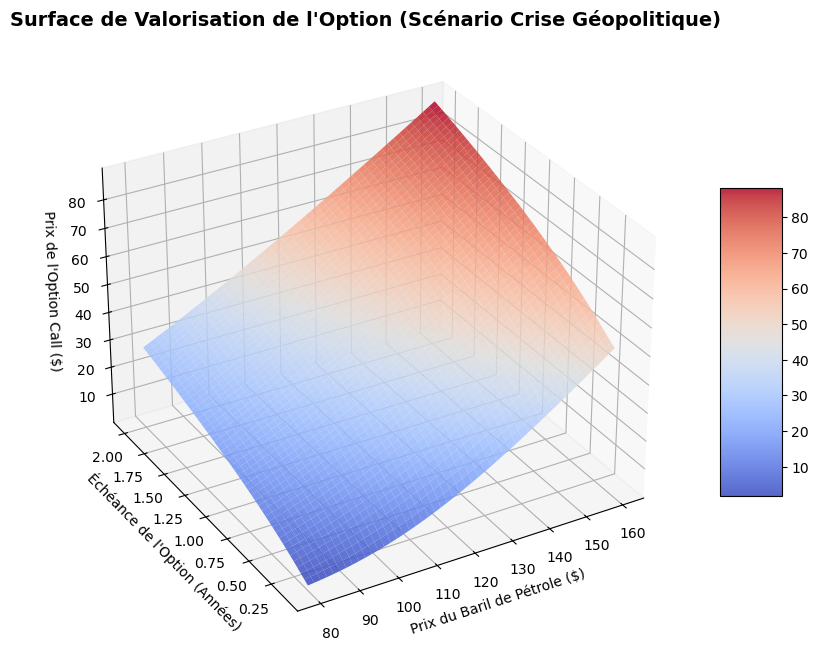

In [21]:
# Création de la grille de valeurs
S_space = np.linspace(80, 160, 50)   # Prix du baril de 80$ à 160$
T_space = np.linspace(0.1, 2.0, 50)  # Échéance de 0.1 à 2 ans
S_mesh, T_mesh = np.meshgrid(S_space, T_space)

# Scénario : crise géopolitique majeure
vol_guerre = 0.80
K_strike = 110

# Calcul vectorisé du prix de l'option sur toute la grille
v_black_scholes = np.vectorize(black_scholes_call)
Z_prices = v_black_scholes(S_mesh, K_strike, T_mesh, 0.04, vol_guerre)

# Tracé de la surface 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    S_mesh, T_mesh, Z_prices,
    cmap=cm.coolwarm,
    linewidth=0,
    antialiased=True,
    alpha=0.85
)

ax.set_title("Surface de Valorisation de l'Option (Scénario Crise Géopolitique)",
             fontsize=14, fontweight='bold')
ax.set_xlabel('Prix du Baril de Pétrole ($)')
ax.set_ylabel("Échéance de l'Option (Années)")
ax.set_zlabel("Prix de l'Option Call ($)")

fig.colorbar(surf, shrink=0.5, aspect=5)
ax.view_init(elev=30, azim=-120)

plt.show()


## Conclusions

Ce projet m'a appris trois choses concrètes :

**1. La volatilité change tout.**  
En passant de 25% (marché calme) à 80% (crise Iran-USA), le prix d'une option peut être multiplié par 3 ou 4. C'est le Vega qui commande.

**2. Monte Carlo et Black-Scholes convergent.**  
Les deux méthodes donnent des résultats quasi-identiques — c'est rassurant. Monte Carlo a l'avantage de visualiser l'éventail des scénarios possibles.

**3. La géopolitique n'est pas un bruit de fond.**  
C'est un input direct dans les modèles de pricing. Un risk manager qui ignore les tensions géopolitiques rate une composante majeure du risque.

---

**Prochaine étape :** stress testing — simuler des chocs extrêmes sur un portefeuille entier et mesurer combien de temps il résiste.